In [32]:
import matplotlib.pyplot as plt
import numpy as np

In [33]:
def lowpass_cosine(freqs, cutoff):
    H = np.zeros_like(freqs, dtype=float)     #Make an array of zeros with the size of freqs
    mask = np.abs(freqs) <= cutoff            #Mark the freqs that are less than cutoff freq
    H[mask] = np.abs(freqs)*(np.cos(np.pi * np.abs(freqs[mask]) / (2 * cutoff)))     #Only apply filter to the ones that are less than cutoff freq
    return H

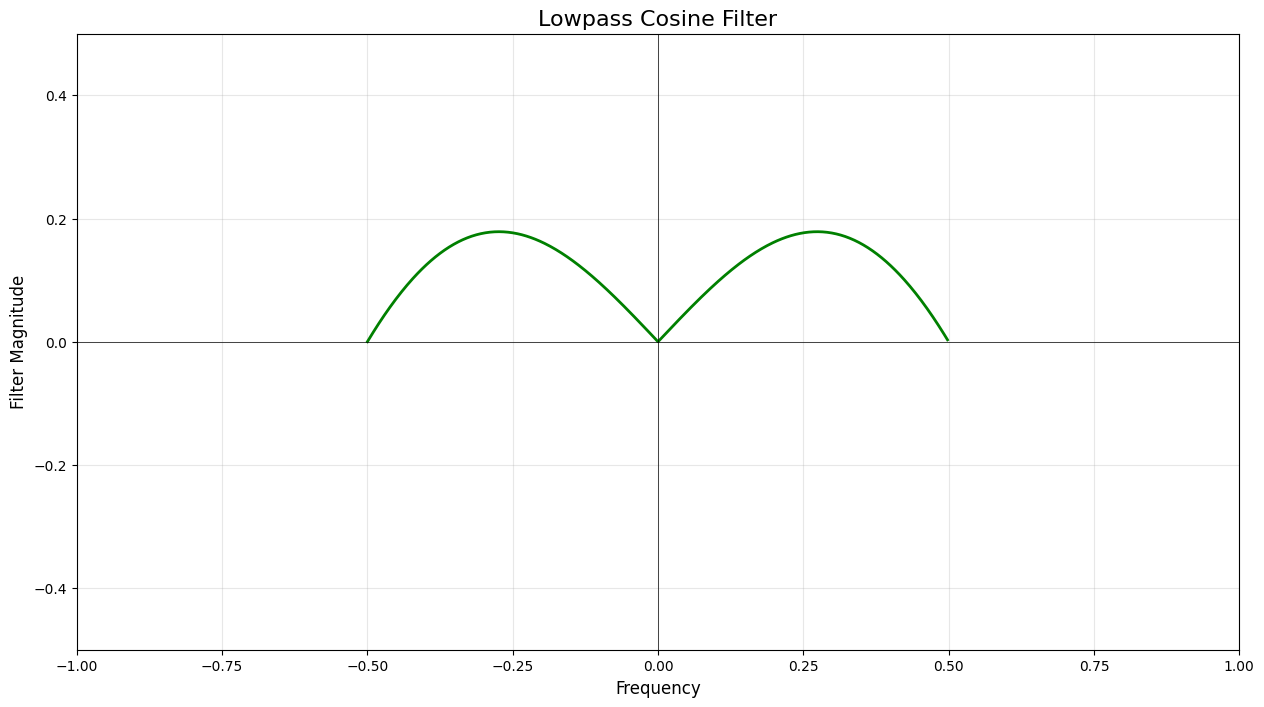

In [34]:
n_detectors = 512
freq_cutoff = 0.5         # Cutoff frequency

# Generate frequencies
freqs = np.fft.fftfreq(n_detectors)

lowpass_cosine = lowpass_cosine(freqs, freq_cutoff)

shifted_freqs = np.fft.fftshift(freqs)
shifted_filter = np.fft.fftshift(lowpass_cosine)

# Plot
plt.figure(figsize=(15, 8))
plt.plot(shifted_freqs, shifted_filter, 'g-', linewidth=2)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Filter Magnitude', fontsize=12)
plt.title('Lowpass Cosine Filter', fontsize=16)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.xlim(-1, 1)
plt.ylim(-0.5, 0.5)
plt.show()

